In [8]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Библиотеки успешно загружены")


Библиотеки успешно загружены


In [9]:
# Генерация набора данных
def make_data(n, seed):
    np.random.seed(seed)
    shift_matrix = np.array([[3, 3], [6, 9], [9, 3]])
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))
    data = np.swapaxes(data, 1, 2)
    data = data.reshape((-1, 2))
    data *= np.array([[20, 0.5]])
    df = pd.DataFrame({'x': data[:, 0], 'y': data[:, 1]})
    df = df.sample(frac=1.0).reset_index(drop=True)
    return df

df = make_data(n=100, seed=42)
print("Первые 5 строк данных:")
print(df.head())
print(f"\nРазмер данных: {df.shape}")


Первые 5 строк данных:
            x         y
0   20.248622  2.860085
1   64.839245  1.530115
2  170.998691  1.174679
3  123.729086  4.339307
4   55.308257  0.928515

Размер данных: (300, 2)


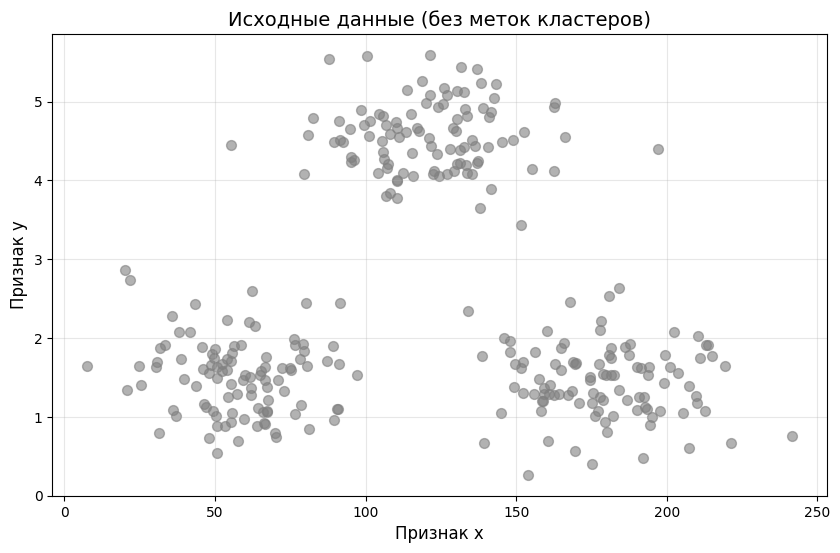

In [10]:
# Визуализация исходных данных
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], c='gray', alpha=0.6, s=50)
plt.title('Исходные данные (без меток кластеров)', fontsize=14)
plt.xlabel('Признак x', fontsize=12)
plt.ylabel('Признак y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("Стандартизация выполнена")
print(f"Среднее после стандартизации: {X_scaled.mean(axis=0).round(2)}")
print(f"Стандартное отклонение после стандартизации: {X_scaled.std(axis=0).round(2)}")


Стандартизация выполнена
Среднее после стандартизации: [-0.  0.]
Стандартное отклонение после стандартизации: [1. 1.]


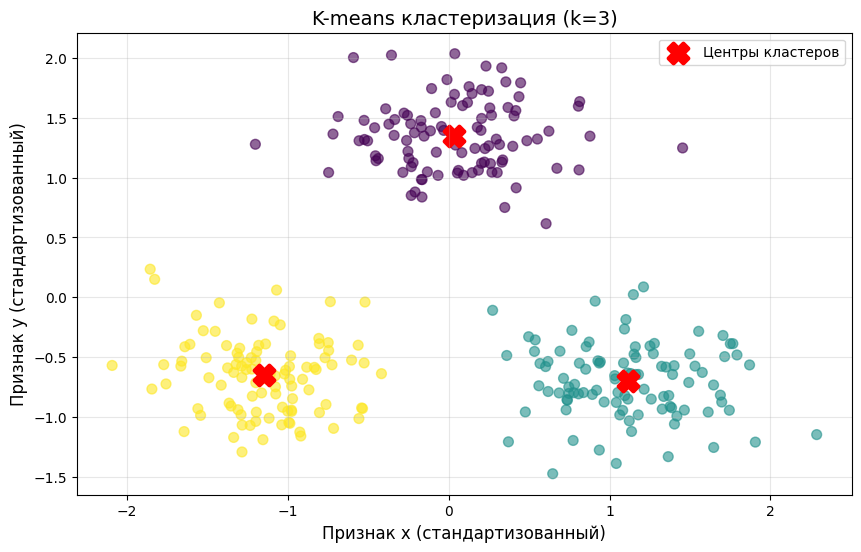

Коэффициент силуэта для k=3: 0.7186


In [12]:
# Кластеризация K-means для k = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_3 = kmeans_3.fit_predict(X_scaled)
centers_3 = kmeans_3.cluster_centers_
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_3, cmap='viridis', alpha=0.6, s=50)
plt.scatter(centers_3[:, 0], centers_3[:, 1], c='red', marker='X', s=200, linewidths=3, label='Центры кластеров')
plt.title('K-means кластеризация (k=3)', fontsize=14)
plt.xlabel('Признак x (стандартизованный)', fontsize=12)
plt.ylabel('Признак y (стандартизованный)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
sil_score_3 = silhouette_score(X_scaled, clusters_3)
print(f"Коэффициент силуэта для k=3: {sil_score_3:.4f}")


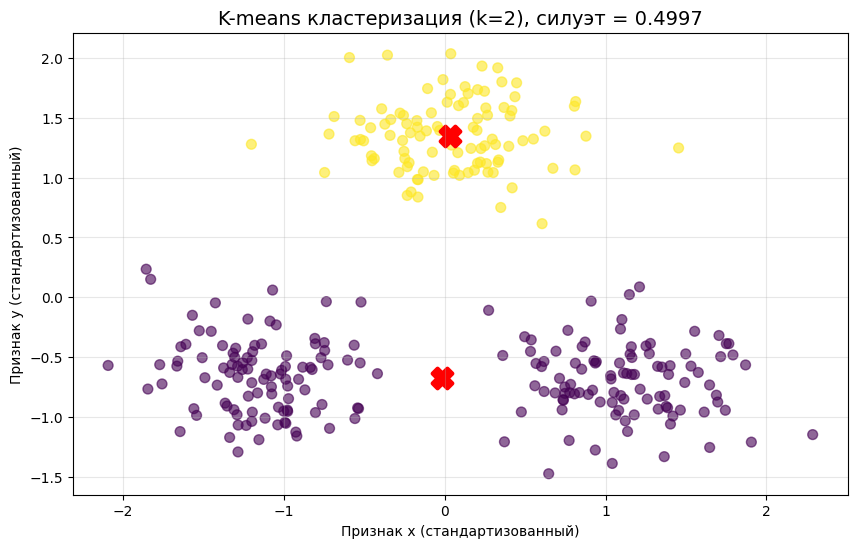

Коэффициент силуэта для k=2: 0.4997


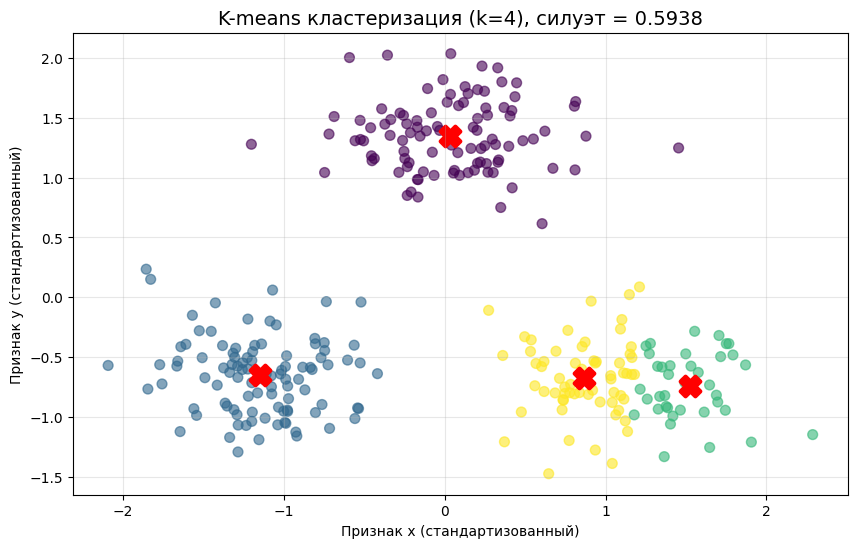

Коэффициент силуэта для k=4: 0.5938


In [13]:
# Кластеризация для k = 2 и k = 4
# k = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_2 = kmeans_2.fit_predict(X_scaled)
sil_score_2 = silhouette_score(X_scaled, clusters_2)
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_2, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, linewidths=3)
plt.title(f'K-means кластеризация (k=2), силуэт = {sil_score_2:.4f}', fontsize=14)
plt.xlabel('Признак x (стандартизованный)')
plt.ylabel('Признак y (стандартизованный)')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Коэффициент силуэта для k=2: {sil_score_2:.4f}")

# k = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_4 = kmeans_4.fit_predict(X_scaled)
sil_score_4 = silhouette_score(X_scaled, clusters_4)
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_4, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans_4.cluster_centers_[:, 0], kmeans_4.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, linewidths=3)
plt.title(f'K-means кластеризация (k=4), силуэт = {sil_score_4:.4f}', fontsize=14)
plt.xlabel('Признак x (стандартизованный)')
plt.ylabel('Признак y (стандартизованный)')
plt.grid(True, alpha=0.3)
plt.show()
print(f"Коэффициент силуэта для k=4: {sil_score_4:.4f}")


In [14]:
# Сравнение результатов
comparison = pd.DataFrame({
    'Количество кластеров (k)': [2, 3, 4],
    'Коэффициент силуэта': [sil_score_2, sil_score_3, sil_score_4],
    'Инерция': [kmeans_2.inertia_, kmeans_3.inertia_, kmeans_4.inertia_]
})
print(comparison)


   Количество кластеров (k)  Коэффициент силуэта     Инерция
0                         2             0.499694  327.114347
1                         3             0.718633   70.669262
2                         4             0.593757   60.318747


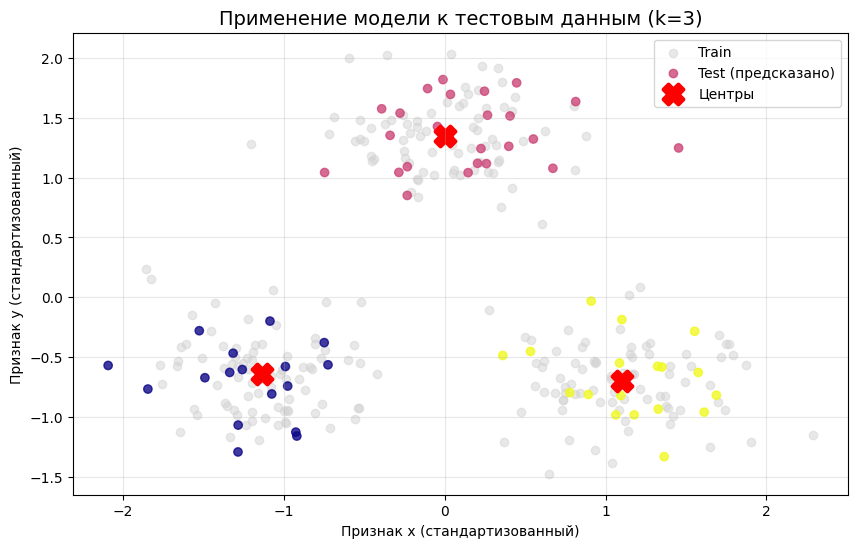

In [15]:
# Применение модели к тестовым данным
# Разделение на train/test (80/20)
split = int(0.8 * len(X_scaled))
X_train = X_scaled[:split]
X_test = X_scaled[split:]
kmeans_train = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_train.fit(X_train)
pred_test = kmeans_train.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c='lightgray', alpha=0.5, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=pred_test, cmap='plasma', alpha=0.8, label='Test (предсказано)')
plt.scatter(kmeans_train.cluster_centers_[:, 0], kmeans_train.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, linewidths=3, label='Центры')
plt.title('Применение модели к тестовым данным (k=3)', fontsize=14)
plt.xlabel('Признак x (стандартизованный)')
plt.ylabel('Признак y (стандартизованный)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


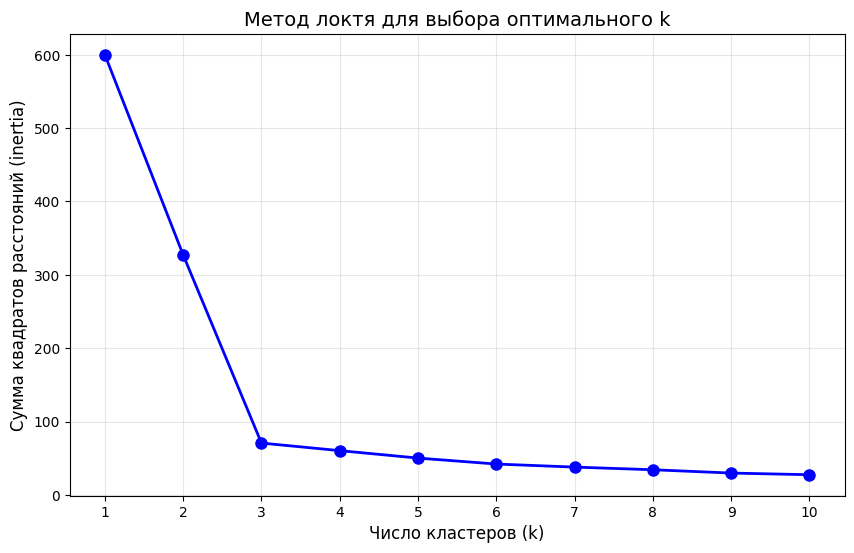

In [16]:
# Метод локтя (Elbow Method)
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Сумма квадратов расстояний (inertia)', fontsize=12)
plt.title('Метод локтя для выбора оптимального k', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()
